In [1]:
from RamanModel import *
from HelperFunctions import *
from Plots import *
from lmfit import Model, Parameters
from numba import njit

In [2]:
@njit(fastmath=True)
def add_lorentzian(curve, x, x0, gamma, maximum):
    gamma_sq = gamma * gamma

    for i in range(len(x)):
        dx = x[i] - x0
        curve[i] += (maximum * gamma_sq) / (gamma_sq + dx * dx)

def knnFit_persistent(samples, base_parameters, target_x, target_y, num_peaks=4, k=10, rounds=3, eps=0.15):
    peak_search_spaces = []
    for _ in range(num_peaks):
        peak_search_spaces.append({
            "center_range": list(base_parameters["center_range"]),
            "amplitude_range": list(base_parameters["amplitude_range"]),
            "gamma_range": list(base_parameters["gamma_range"])
        })

    # MOVE HEAP OUTSIDE THE ROUNDS LOOP
    heap = []
    best_neighbor_params = []

    # DEFINE X RANGE FOR PROB MAP SAMPLING
    x_range = np.linspace(0, 1, len(target_y))

    # CALCULATE PROBABILITY MAP FOR FIRST PASS
    probs = create_probability_map(target_y, num_peaks=num_peaks, resolution=50)

    #######################################################
    #################### FIRST PASS #######################
    #######################################################
    #print("Round 1 - Exploring with probability map")
    """
    current_y = np.empty_like(target_x)
    for i in range(samples): #THIS LOOKS SO UGLY BLEACH MY EYES
            #current_y = np.zeros(len(target_x))
            current_y.fill(0.0)
            current_params = []

            for i in range(num_peaks):
                p = peak_search_spaces[i]
                #position_interval = position_probability_map(probs, x_range)
                #c = np.random.uniform(position_interval[0], position_interval[1])
                c = position_probability_map(probs, x_range)
                a = np.random.uniform(p["amplitude_range"][0], p["amplitude_range"][1])
                g = np.random.uniform(p["gamma_range"][0], p["gamma_range"][1])

                #current_y += lorentzian(target_x, c, g, a)
                add_lorentzian(current_y, target_x, c, g, a)
                current_params.append({"center": c, "amplitude": a, "gamma": g})
            
            max_point = np.max(current_y)
            if max_point > 0:
                current_y /= max_point

            dist = euclidean_distance(target_y, current_y)

            if len(heap) < k:
                heapq.heappush(heap, (-dist, current_params))
            else:
                if -dist > heap[0][0]:
                    heapq.heapreplace(heap, (-dist, current_params))
    """

    #######################################################
    ##################### Nth PASS ########################
    #######################################################
    
    for r in range(rounds):
        current_y = np.empty_like(target_x)
        
        # INITIALIZE PARAMETERS

        centers = np.empty((samples, num_peaks))
        amps    = np.empty((samples, num_peaks))
        gammas  = np.empty((samples, num_peaks))

        for i in range(num_peaks):
            p = peak_search_spaces[i]
        
            centers[:, i] = np.random.uniform(
                p["center_range"][0],
                p["center_range"][1],
                size=samples
            )
        
            amps[:, i] = np.random.uniform(
                p["amplitude_range"][0],
                p["amplitude_range"][1],
                size=samples
            )
        
            gammas[:, i] = np.random.uniform(
                p["gamma_range"][0],
                p["gamma_range"][1],
                size=samples
            )

        # START LOOP
        
        for sample_idx in range(samples):
            #current_y = np.zeros(len(target_x))
            current_y.fill(0.0)
            current_params = []

            for i in range(num_peaks):
                p = peak_search_spaces[i]

                if (r == 0):
                    c = position_probability_map(probs, x_range)
                else:
                    c = centers[sample_idx, i]
                a = amps[sample_idx, i]
                g = gammas[sample_idx, i]

                #current_y += lorentzian(target_x, c, g, a)
                #add_lorentzian(current_y, target_x, c, g, a)
                add_lorentzian(current_y, target_x, c, g, a)
                current_params.append({"center": c, "amplitude": a, "gamma": g})

            max_point = np.max(current_y)
            if max_point > 0:
                current_y /= max_point

            dist = euclidean_distance(target_y, current_y)

            if len(heap) < k:
                heapq.heappush(heap, (-dist, current_params))
            else:
                if -dist > heap[0][0]:
                    heapq.heapreplace(heap, (-dist, current_params))

        # --- DBSCAN-Style Clustering with Origin Tracking ---
        nearest_neighbors = [item[1] for item in heap]
        #print(nearest_neighbors)

        all_candidate_peaks = []
        for neighbor_id, neighbor_params in enumerate(nearest_neighbors):
            for peak in neighbor_params:
                # Store the peak data AND which curve it belongs to
                all_candidate_peaks.append({
                    "data": peak,
                    "origin_curve": neighbor_id
                })

        visited = [False] * len(all_candidate_peaks)
        valid_clusters = []

        for i in range(len(all_candidate_peaks)):
            if visited[i]: continue

            cluster_indices = [i]
            # Tracking which curves have contributed to this cluster
            curves_in_cluster = {all_candidate_peaks[i]["origin_curve"]}

            for j in range(len(all_candidate_peaks)):
                if i == j: continue

                dist = get_param_distance(
                    all_candidate_peaks[i]["data"],
                    all_candidate_peaks[j]["data"],
                    base_parameters
                )

                if dist < eps:
                    cluster_indices.append(j)
                    curves_in_cluster.add(all_candidate_peaks[j]["origin_curve"])

            # CRITICAL CHECK: Does a majority of DIFFERENT curves agree?
            if len(curves_in_cluster) > (k // 2):
                valid_clusters.append(cluster_indices)
                # Mark peaks in this cluster as visited
                for idx in cluster_indices:
                    visited[idx] = True

        # Sort and update search spaces
        valid_clusters.sort(key=lambda c_idx: np.mean([all_candidate_peaks[idx]['data']['center'] for idx in c_idx]))

        for p_idx, cluster_indices in enumerate(valid_clusters[:num_peaks]):
            c_vals = [all_candidate_peaks[i]['data']['center'] for i in cluster_indices]
            a_vals = [all_candidate_peaks[i]['data']['amplitude'] for i in cluster_indices]
            g_vals = [all_candidate_peaks[i]['data']['gamma'] for i in cluster_indices]

            peak_search_spaces[p_idx]["center_range"] = [min(c_vals), max(c_vals)]
            peak_search_spaces[p_idx]["amplitude_range"] = [min(a_vals), max(a_vals)]
            peak_search_spaces[p_idx]["gamma_range"] = [min(g_vals), max(g_vals)]

            #print(f"Round {r+2}: Peak {p_idx} search space narrowed (Agreed by {len(curves_in_cluster)} unique curves)")

        best_neighbor_params = nearest_neighbors[0]
        #print(f"Round {r+2} Best Distance: {-heap[0][0]:.4f}")

    return best_neighbor_params, nearest_neighbors

In [3]:
import matplotlib.pyplot as plt

# --- 1. Generate the "Target" Curve ---
parameters = {
    "center_range": (0.1, 0.9),
    "amplitude_range": (0.1, 1.0),
    "gamma_range": (0.01, 0.05),
    "x_min": 0,
    "x_max": 1
}

# Generate a target with 4 peaks and some noise
target_x, target_y, target_params = generateCurve(parameters, 4, 1000, 0.2)
target_y = downsample_and_normalize(target_y, resolution=1000)

In [8]:
import time
import cProfile
import pstats

profiler = cProfile.Profile()
profiler.enable()

t0 = time.perf_counter()

best_params, neighbors_params = knnFit_persistent(
    #samples=30000,
    samples=10000,
    base_parameters=parameters,
    target_x=target_x,
    target_y=target_y,
    k=5,
    rounds=5,
    eps=0.15
)

t1 = time.perf_counter()

profiler.disable()

stats = pstats.Stats(profiler)
stats.sort_stats("cumtime")
stats.print_stats(20)

print(f'Execution time: {(t1 - t0)*1000}ms')

         552166 function calls (552164 primitive calls) in 1.622 seconds

   Ordered by: cumulative time
   List reduced from 98 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        4    0.008    0.002    1.619    0.405 {built-in method builtins.exec}
        1    0.000    0.000    1.610    1.610 C:\Users\Saulo\AppData\Local\Temp\ipykernel_11444\3586526107.py:1(<module>)
        1    1.131    1.131    1.610    1.610 C:\Users\Saulo\AppData\Local\Temp\ipykernel_11444\3220059816.py:9(knnFit_persistent)
    50000    0.057    0.000    0.359    0.000 E:\Root\Faculdade\Raman Fitting Pipeline\Raman-Fitting-Pipeline\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3011(max)
    50002    0.098    0.000    0.302    0.000 E:\Root\Faculdade\Raman Fitting Pipeline\Raman-Fitting-Pipeline\venv\Lib\site-packages\numpy\_core\fromnumeric.py:66(_wrapreduction)
    50019    0.190    0.000    0.190    0.000 {method 'reduce' of 'numpy.ufunc' objects}

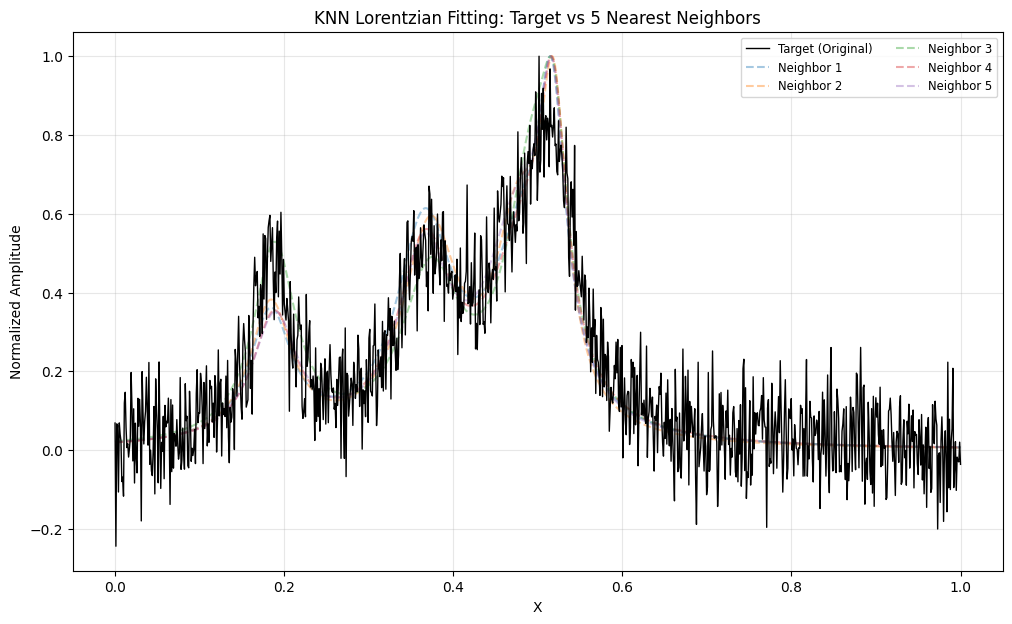

In [7]:
PlotNeighbors(best_params, neighbors_params, target_x, target_y)